In [10]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

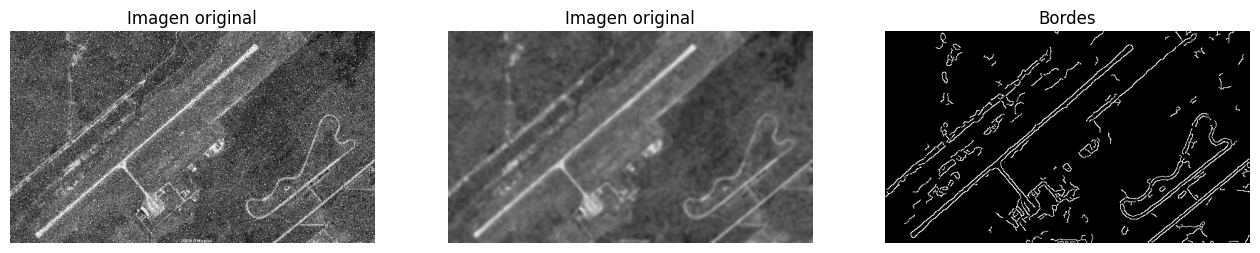

In [11]:
img = cv2.imread('../Imagenes_cursado/corrientes_ruidogris.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

img_blur = cv2.medianBlur(img, 5)
img_blur = cv2.GaussianBlur(img_blur, (7,7), 1, 1)

img_bordes = cv2.Canny(img_blur, 50, 100)

plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.title("Imagen original")
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis(False)

plt.subplot(1,3,2)
plt.title("Imagen original")
plt.imshow(img_blur, cmap='gray', vmin=0, vmax=255)
plt.axis(False)

plt.subplot(1,3,3)
plt.title("Bordes")
plt.imshow(img_bordes, cmap='gray', vmin=0, vmax=255)
plt.axis(False)
plt.show()

In [ ]:
import cv2
import numpy as np

# =====================================================================
# CONFIGURACIÓN GENERAL Y VARIABLES GLOBALES
# =====================================================================
WINDOW_CTRL = "Controles"
WINDOW_RES = "Resultado HoughP"

# Definimos los nombres exactos de los Trackbars aquí para no errarle
TRACKBAR_RHO = "Rho"
TRACKBAR_THETA = "Theta (grados)"
TRACKBAR_THRESH = "P-threshold"
TRACKBAR_MIN_LEN = "P-minLineLength"
TRACKBAR_MAX_GAP = "P-maxLineGap"

# =====================================================================
# FUNCIÓN DE PROCESAMIENTO (CALLBACK)
# =====================================================================
def procesar_hough(_=None):
    try:
        rho = max(cv2.getTrackbarPos(TRACKBAR_RHO, WINDOW_CTRL), 1)
        theta_deg = max(cv2.getTrackbarPos(TRACKBAR_THETA, WINDOW_CTRL), 1)
        threshold = cv2.getTrackbarPos(TRACKBAR_THRESH, WINDOW_CTRL)
        min_line_len = cv2.getTrackbarPos(TRACKBAR_MIN_LEN, WINDOW_CTRL)
        max_line_gap = cv2.getTrackbarPos(TRACKBAR_MAX_GAP, WINDOW_CTRL)

        theta_step = theta_deg * np.pi / 180
        bordes_input = img_bordes.copy()
        
        linesP = cv2.HoughLinesP(
            bordes_input,
            rho,
            theta_step,
            threshold,
            None,
            minLineLength=min_line_len,
            maxLineGap=max_line_gap
        )

        lienzo_salida = cv2.cvtColor(bordes_input, cv2.COLOR_GRAY2BGR)

        if linesP is not None:
            for i in range(len(linesP)):
                l = linesP[i][0]
                cv2.line(lienzo_salida, (l[0], l[1]), (l[2], l[3]), (0, 0, 255), 3, cv2.LINE_AA)

        cv2.imshow(WINDOW_RES, lienzo_salida)
        
    except cv2.error:

        pass

cv2.namedWindow(WINDOW_CTRL, cv2.WINDOW_NORMAL)
cv2.namedWindow(WINDOW_RES, cv2.WINDOW_AUTOSIZE)
cv2.namedWindow("Original", cv2.WINDOW_AUTOSIZE)


cv2.imshow("Original", img)


cv2.createTrackbar(TRACKBAR_RHO, WINDOW_CTRL, 1, 100, procesar_hough)
cv2.createTrackbar(TRACKBAR_THETA, WINDOW_CTRL, 1, 100, procesar_hough)
cv2.createTrackbar(TRACKBAR_THRESH, WINDOW_CTRL, 1, 200, procesar_hough)
cv2.createTrackbar(TRACKBAR_MIN_LEN, WINDOW_CTRL, 1, 1000, procesar_hough)
cv2.createTrackbar(TRACKBAR_MAX_GAP, WINDOW_CTRL, 1, 500, procesar_hough)

procesar_hough()

print("Programa corriendo sin errores. Presiona 'c' para cerrar.")

while True:
    key = cv2.waitKey(50) & 0xFF
    if key == ord('c'):
        break

cv2.destroyAllWindows()

Programa corriendo sin errores. Presiona 'c' para cerrar.


KeyboardInterrupt: 

Imagen corrientes_ruidogris
- Rho = 0
- Theta = 49
- P-threshold = 1
- P-minLineLength = 286
- P-maxLineGap = 41

Imagen iguazu_ruidogris
- Rho = 1
- Theta = 1
- P-threshold = 1
- P-minLineLength = 315
- P-maxLineGap = 114